<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:50px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Image combination
  </span>
</h1>

Image combination serves several purposes. Combining images:

- Reduces noises in images;
- Can remove transient artifacts like cosmic rays and satellite tracks;
- Can remove stars in flat images taken at twilight.

It’s essential that several of each type of calibration image (bias, dark, flat) be taken. Combining them reduces the noise in the images by roughly a factor of $\frac{1}{\sqrt N}$, where ***N*** is the number of images being combined. As shown in the previous notebook, using a single calibration image actually *increases* the noise in your image.

There are a few ways to combine images; if done properly, features that show up in only one of the images (like cosmic rays) are not present in the combination. If done incorrectly, those features show up in your combined images and then *contaminate* your calibrated science images too.

---
# The bottom line: combine by averaging images, but clip extreme values


The remainder of this notebook demonstrates this conclusion and explains how to do a combination by averaging images with [ccdproc](https://ccdproc.readthedocs.io/en/latest/)

*ccdproc* is a Python library used as a tool for basic CCD camera data processing; it works in conjunction with astropy. (examples: `astropy.nddata`, `astropy.units`, etc.). Its main goal is to automate and standardize the CCD image calibration process (bias correction, dark correction, flat correction, image combination) — which is what we will focus on in this tutorial.

In [2]:
import os
import numpy as np

%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import rc #runtime configuration, changes the default settings that control the appearance of all charts you create after that

from astropy.visualization import hist #histograms 
from astropy.stats import mad_std 
#Median Absolute Deviation, It’s a way to measure how widely the data is distributed (dispersion), 
#but in a way that outliers don’t interfere. it uses the median instead of the mean, which makes it resistant to outliers (extreme values)

plt.style.use('guide.mplstyle')
rc('font', size=20)
rc('axes', grid=True)

seed = os.getenv('GUIDE_RANDOM_SEED', None) #allows you to control randomness without changing the code
if seed is not None:
    seed = int(seed)

noise_rng = np.random.default_rng(seed)
# seed = random number generator 
# it retrieves the value of an environment variable (settings that exist outside your Python code, in the operating system—think of them as “global preferences”)

# Combination method: average or median?

In this section we’ll look at a simplified version of the challenges of combining images to reduce noise. It’s fair to think of astronomical images (especially bias and dark images) as being a Gaussian distribution of pixel values around the bias level, and a width related to the read noise of the detector. To simplify what follows, we will work arrays of random numbers drawn from a Gaussian distribution instead of with astronomical images.

In properly done flat images the noise is technically a Poisson distribution, but with a large enough number of counts, the distribution is indistinguishable from a Gaussian distribution whose width is related to the square root of the number of counts. While some regions of a science image are dominated by Poisson noise from sources in the image, most of the image will be dominated by Gaussian read noise from the detector or Poisson noise from the sky background.

Instead of working with a combination of images, <u>we’ll create 100 Gaussian distributions with a mean of zero</u>, and a standard deviation of one, and combine those two different ways: by <u>finding the average and by finding the median.</u> Each distribution has size $320^2$ so that we can view it as either a distribution of 102,400 values or as an image that is $3200\times 320$.

We can think of each of these 100 distributions as representing an image, like a bias or dark. To make the analogy to real images a little more direct, a “bias” of 1000 is added to each distribution.

*vamos criar 100 distribuições Gaussianas artificiais (cada uma com 102.400 pontos, que seria o equivalente a uma imagem de 320×320 pixels), com média = 0 e desvio padrão = 1. Isso para testar como combinar essas 100 "imagens" de duas formas diferentes: tirando a média e tirando a mediana.*

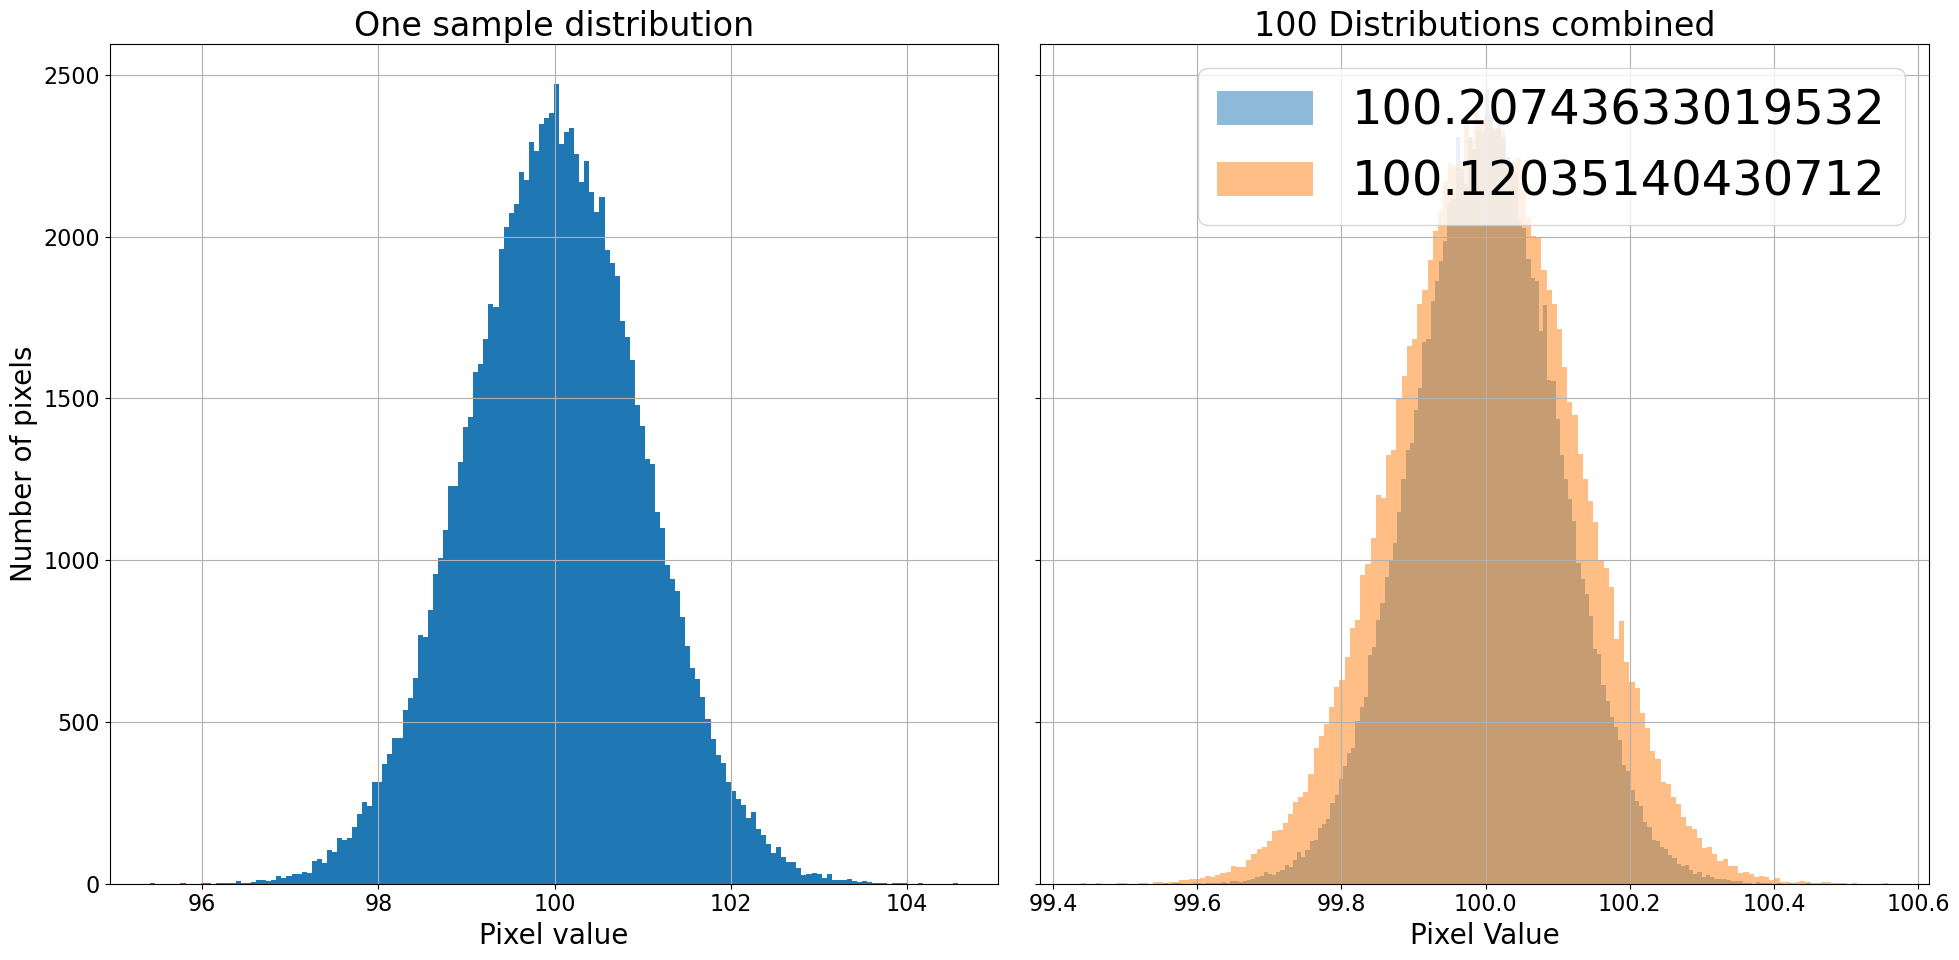

In [7]:
n_distributions = 100
bias_level = 100
n_side = 320
bits = noise_rng.normal(size=(n_distributions, n_side**2)) + bias_level 
average = np.average(bits, axis=0)
median = np.median(bits, axis=0)

#Now that we’ve created the distributions and combined them in two different ways, let’s take a look at them. 
#The hist function from astropy.visualization (see "links") is used below because it can figure out what bin size to use for your data.

fig, ax = plt.subplots(1, 2, sharey=True, tight_layout=True, figsize=(20, 10))

hist(bits[0, :], bins='freedman', ax=ax[0]);
ax[0].set_title('One sample distribution')
ax[0].set_xlabel('Pixel value')
ax[0].set_ylabel('Number of pixels')

hist(average, bins='freedman', label=average, alpha=0.5, ax=ax[1]);
hist(median, bins='freedman', label=median, alpha=0.5, ax=ax[1]);
ax[1].set_title('{} Distributions combined'.format(n_distributions))
ax[1].set_xlabel('Pixel Value')
ax[1].legend()

Combining by averaging gives a narrower (i.e. less noisy) distribution than combining by median, though both substantially reduced the width of the distribution. <u>The conclusion so far is that combining by averaging is mildly preferable to combining by median. **Computationally, the mean is also faster to compute than the median.** </u>

---

# Image view of these distributions

As suggested above, we could view each of these distributions as an image instead of a histogram. One take away from the diagram below is that in this case, the difference between mean and median <u>is not apparent. </u>

In all cases, the extreme values of the image display are set to bracket the width of the initial distribution.

In [ ]:
fig, axes

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Notes
  </span>
</h1>

- Lembrar que:
    - Distribuição Gaussiana é uma forma de descrever como os dados se espalham ao redor de um valor central.
    - Distribuição de Poisson é uma distribuição de probabilidade discreta que modela o número de eventos ocorrendo em um intervalo fixo de tempo, espaço ou volume. Ela é aplicável quando eventos ocorrem independentemente a uma taxa média constante
    - Poisson vira Gaussiana quando a média é grande (flats bem expostos (muitos fótons) podem ser tratados como Gaussianos).

---

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Links
  </span>
</h1>

https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://github.com/nyny2903/astropy-coisas/tree/main<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-06-Image-combination.html

https://ccdproc.readthedocs.io/en/latest/<br>https://docs.astropy.org/en/stable/visualization/histogram.html